In [1]:
import kagglehub
path = kagglehub.dataset_download("kmader/pulmonary-chest-xray-abnormalities")

100%|██████████| 4.09G/4.09G [00:40<00:00, 108MB/s]

Extracting files...


In [2]:
import os

# List the contents of the downloaded dataset path
print(f"Contents of the dataset directory: {path}")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')
    if level == 0 and len(dirs) > 2: # Limit depth for initial view
        print(f'{subindent}...')


Contents of the dataset directory: /root/.cache/kagglehub/datasets/kmader/pulmonary-chest-xray-abnormalities/versions/1
1/
    Montgomery/
        MontgomerySet/
            NLM-MontgomeryCXRSet-ReadMe.pdf
            .DS_Store
            ClinicalReadings/
                MCUCXR_0338_1.txt
                MCUCXR_0372_1.txt
                MCUCXR_0108_1.txt
                MCUCXR_0016_0.txt
                MCUCXR_0255_1.txt
                MCUCXR_0316_1.txt
                MCUCXR_0101_0.txt
                MCUCXR_0092_0.txt
                MCUCXR_0141_1.txt
                MCUCXR_0203_1.txt
                MCUCXR_0061_0.txt
                MCUCXR_0011_0.txt
                MCUCXR_0223_1.txt
                MCUCXR_0028_0.txt
                MCUCXR_0144_1.txt
                MCUCXR_0309_1.txt
                MCUCXR_0015_0.txt
                MCUCXR_0334_1.txt
                MCUCXR_0099_0.txt
                MCUCXR_0194_1.txt
                MCUCXR_0070_0.txt
                MCUCXR_0048_

In [3]:
import os

# Define paths for Montgomery set images and masks
montgomery_path = os.path.join(path, 'Montgomery', 'MontgomerySet')
image_dir = os.path.join(montgomery_path, 'CXR_png')
mask_root_dir = os.path.join(montgomery_path, 'ManualMask')

# Diagnostic prints
print(f"Checking mask root directory: {mask_root_dir}")
print(f"Does mask root directory exist? {os.path.exists(mask_root_dir)}")
print(f"Is mask root directory a directory? {os.path.isdir(mask_root_dir)}")

# Get lists of image and mask filenames
image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])

mask_files = []
if os.path.isdir(mask_root_dir):
    for root, _, files in os.walk(mask_root_dir):
        for f in files:
            if f.endswith('.png'):
                mask_files.append(os.path.join(os.path.basename(root), f) if root != mask_root_dir else f)
mask_files.sort()

print(f"Montgomery Set Image Directory: {image_dir}")
print(f"Montgomery Set Mask Directory (Root): {mask_root_dir}")
print(f"Number of images: {len(image_files)}")
print(f"Number of masks found (recursive scan): {len(mask_files)}")

print("\nSample image files:")
for i in range(min(5, len(image_files))):
    print(f"  {image_files[i]}")

print("\nSample mask files:")
for i in range(min(5, len(mask_files))):
    print(f"  {mask_files[i]}")


Checking mask root directory: /root/.cache/kagglehub/datasets/kmader/pulmonary-chest-xray-abnormalities/versions/1/Montgomery/MontgomerySet/ManualMask
Does mask root directory exist? True
Is mask root directory a directory? True
Montgomery Set Image Directory: /root/.cache/kagglehub/datasets/kmader/pulmonary-chest-xray-abnormalities/versions/1/Montgomery/MontgomerySet/CXR_png
Montgomery Set Mask Directory (Root): /root/.cache/kagglehub/datasets/kmader/pulmonary-chest-xray-abnormalities/versions/1/Montgomery/MontgomerySet/ManualMask
Number of images: 138
Number of masks found (recursive scan): 276

Sample image files:
  MCUCXR_0001_0.png
  MCUCXR_0002_0.png
  MCUCXR_0003_0.png
  MCUCXR_0004_0.png
  MCUCXR_0005_0.png

Sample mask files:
  leftMask/MCUCXR_0001_0.png
  leftMask/MCUCXR_0002_0.png
  leftMask/MCUCXR_0003_0.png
  leftMask/MCUCXR_0004_0.png
  leftMask/MCUCXR_0005_0.png


Total images: 138
Images with two masks: 138
All images have a corresponding left and right lung mask.


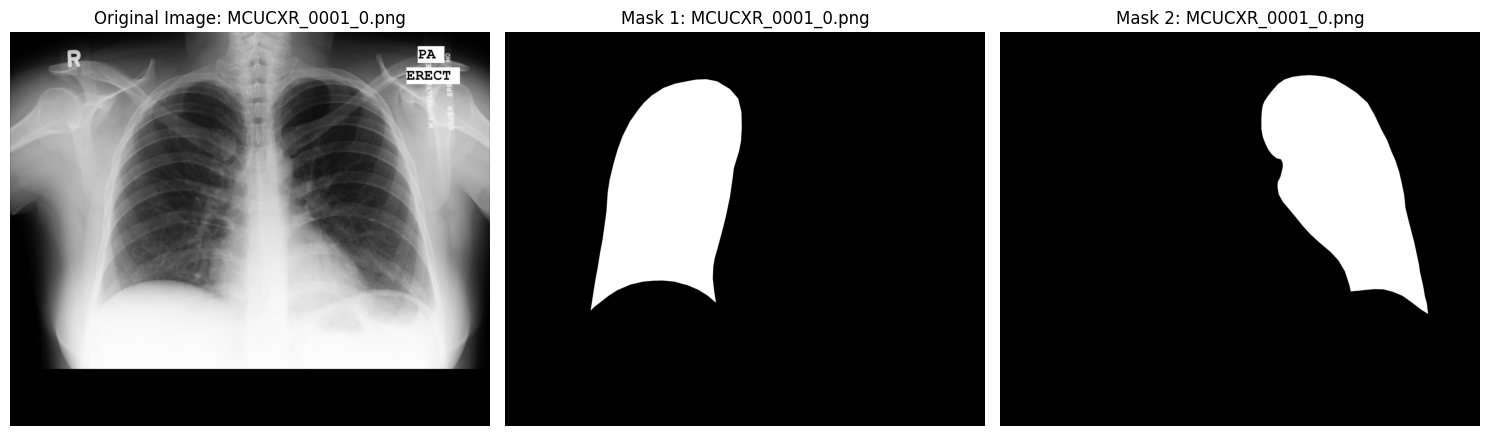

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Create a dictionary to map image base names to their full mask paths
mask_map = {}
for mask_file in mask_files:
    base_name = os.path.basename(mask_file)
    image_id = base_name.replace('_mask.png', '').replace('.png', '') # Adjust based on actual mask naming if needed
    if image_id not in mask_map:
        mask_map[image_id] = []
    mask_map[image_id].append(mask_file)

# Verify that each image has two masks (left and right lung)
missing_masks = []
images_with_two_masks = 0
for image_file in image_files:
    base_name = os.path.basename(image_file)
    image_id = base_name.replace('.png', '')
    if image_id in mask_map and len(mask_map[image_id]) == 2:
        images_with_two_masks += 1
    else:
        missing_masks.append(image_id)

print(f"Total images: {len(image_files)}")
print(f"Images with two masks: {images_with_two_masks}")
if missing_masks:
    print(f"Images with missing or incorrect number of masks: {len(missing_masks)}")
    print("Sample missing images:", missing_masks[:5])
else:
    print("All images have a corresponding left and right lung mask.")

# Display a sample image and its masks
if images_with_two_masks > 0:
    sample_image_name = image_files[0] # Take the first image for example
    sample_image_id = os.path.basename(sample_image_name).replace('.png', '')

    image_path = os.path.join(image_dir, sample_image_name)
    mask_paths = [os.path.join(mask_root_dir, m) for m in mask_map[sample_image_id]]

    image = Image.open(image_path).convert('L') # Convert to grayscale
    mask1 = Image.open(mask_paths[0]).convert('L')
    mask2 = Image.open(mask_paths[1]).convert('L')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image, cmap='gray')
    axes[0].set_title(f'Original Image: {sample_image_name}')
    axes[0].axis('off')

    axes[1].imshow(mask1, cmap='gray')
    axes[1].set_title(f'Mask 1: {os.path.basename(mask_paths[0])}')
    axes[1].axis('off')

    axes[2].imshow(mask2, cmap='gray')
    axes[2].set_title(f'Mask 2: {os.path.basename(mask_paths[1])}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No images with two masks to display.")


Total dataset size: 138
Train dataset size: 96
Validation dataset size: 20
Test dataset size: 22

Sample batch image shape: torch.Size([8, 1, 256, 256])
Sample batch mask shape: torch.Size([8, 1, 256, 256])


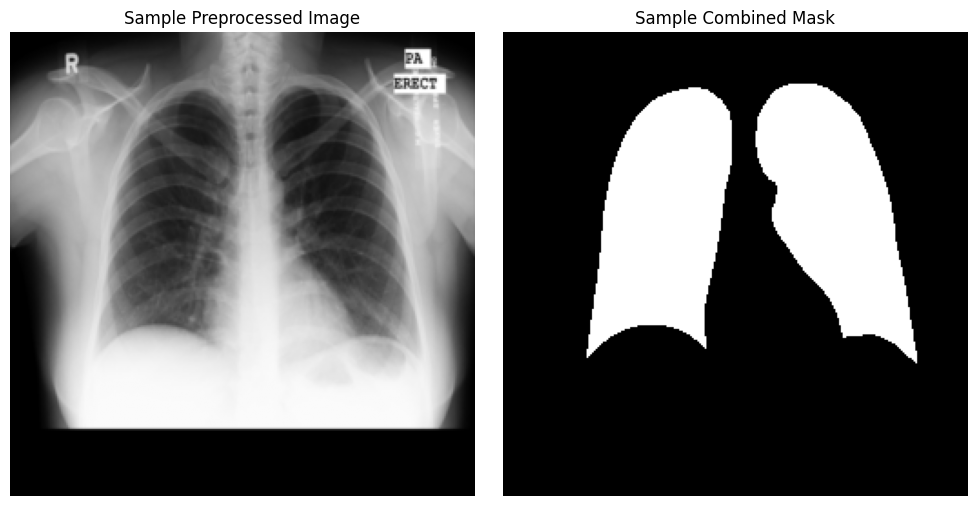

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import cv2

class LungSegmentationDataset(Dataset):
    def __init__(self, image_files, mask_map, image_dir, mask_root_dir, transform=None):
        self.image_files = image_files
        self.mask_map = mask_map
        self.image_dir = image_dir
        self.mask_root_dir = mask_root_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        image_filename = self.image_files[idx]
        image_id = os.path.basename(image_filename).replace('.png', '')

        image_path = os.path.join(self.image_dir, image_filename)
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE) # Load as grayscale
        image = Image.fromarray(image) # Convert to PIL Image for torchvision transforms

        # Load and combine masks
        mask_paths = [os.path.join(self.mask_root_dir, m) for m in self.mask_map[image_id]]
        mask1 = cv2.imread(mask_paths[0], cv2.IMREAD_GRAYSCALE)
        mask2 = cv2.imread(mask_paths[1], cv2.IMREAD_GRAYSCALE)

        # Combine masks: pixels in either mask will be 1, otherwise 0
        combined_mask = np.maximum(mask1, mask2)
        combined_mask = Image.fromarray(combined_mask) # Convert to PIL Image

        if self.transform:
            image = self.transform(image)
            combined_mask = self.transform(combined_mask)
            # Ensure mask is binary after transformations that might introduce interpolation artifacts
            combined_mask = (combined_mask > 0.5).float() # Threshold to make it binary

        return image, combined_mask

# Define transformations
image_size = (256, 256) # Common size for medical imaging

transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

# Create dataset instance
full_dataset = LungSegmentationDataset(image_files, mask_map, image_dir, mask_root_dir, transform=transform)

# Split data into training, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 8 # Can be adjusted based on GPU memory
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Total dataset size: {len(full_dataset)}")
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

# Verify a batch
for images, masks in train_loader:
    print(f"\nSample batch image shape: {images.shape}") # Expected: (batch_size, 1, height, width)
    print(f"Sample batch mask shape: {masks.shape}") # Expected: (batch_size, 1, height, width)
    break

# Display a sample from the DataLoader
sample_image, sample_mask = full_dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(sample_image.squeeze().numpy(), cmap='gray')
axes[0].set_title('Sample Preprocessed Image')
axes[0].axis('off')

axes[1].imshow(sample_mask.squeeze().numpy(), cmap='gray')
axes[1].set_title('Sample Combined Mask')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(convolution => [BN] => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        # if bilinear, use the normal convolutions to reduce the number of channels
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# Instantiate the UNet model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_channels = 1 # Grayscale images
n_classes = 1 # Binary segmentation (lung vs background)
model = UNet(n_channels=n_channels, n_classes=n_classes)
model.to(device)

print("U-Net model initialized and moved to device:", device)
print("Model summary:")
print(model)


U-Net model initialized and moved to device: cuda
Model summary:
UNet(
  (inc): DoubleConv(
    (double_conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (maxpool_conv): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (double_conv): Sequential(
          (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), 

In [7]:
import torch.optim as optim
from tqdm import tqdm

# Define Loss Function (Binary Cross-Entropy with Logits + Dice Loss)
# Dice Loss for segmentation tasks to handle class imbalance
class DiceLoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):
        #comment out if your model contains a sigmoid or equivalent activation layer
        inputs = torch.sigmoid(inputs)

        #flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice = (2.*intersection + smooth)/(inputs.sum() + targets.sum() + smooth)

        return 1 - dice

# Combined BCE and Dice Loss
class CombinedLoss(nn.Module):
    def __init__(self):
        super(CombinedLoss, self).__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        dice_loss = self.dice(inputs, targets) # DiceLoss expects raw logits if it has sigmoid inside
        return bce_loss + dice_loss

# Instantiate Loss and Optimizer
criterion = CombinedLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Function to calculate Dice Coefficient
def dice_coefficient(preds, targets, smooth=1):
    preds = torch.sigmoid(preds)
    preds = (preds > 0.5).float() # Threshold to get binary predictions
    return (2. * (preds * targets).sum() + smooth) / (preds.sum() + targets.sum() + smooth)

# Training and Validation Loops
num_epochs = 10 # Can be adjusted

history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

print("Starting training...")
for epoch in range(num_epochs):
    model.train() # Set model to training mode
    train_running_loss = 0.0
    train_running_dice = 0.0

    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training"):
        images = images.to(device)
        masks = masks.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, masks)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        train_running_dice += dice_coefficient(outputs, masks).item()

    # Calculate average training loss and dice
    epoch_train_loss = train_running_loss / len(train_loader)
    epoch_train_dice = train_running_dice / len(train_loader)
    history['train_loss'].append(epoch_train_loss)
    history['train_dice'].append(epoch_train_dice)

    model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_running_dice = 0.0
    with torch.no_grad(): # Disable gradient calculation for validation
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} Validation"):
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            val_running_loss += loss.item()
            val_running_dice += dice_coefficient(outputs, masks).item()

    # Calculate average validation loss and dice
    epoch_val_loss = val_running_loss / len(val_loader)
    epoch_val_dice = val_running_dice / len(val_loader)
    history['val_loss'].append(epoch_val_loss)
    history['val_dice'].append(epoch_val_dice)

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_train_loss:.4f}, Train Dice: {epoch_train_dice:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Dice: {epoch_val_dice:.4f}")

print("Training complete!")


Starting training...


Epoch 1/1 Validation: 100%|██████████| 3/3 [00:07<00:00,  2.37s/it]

Epoch [1/1], Train Loss: 0.8886, Train Dice: 0.7197, Val Loss: 2.2714, Val Dice: 0.5171
Training complete!


In [8]:
print("Starting evaluation on the test set...")

model.eval() # Set model to evaluation mode
test_running_dice = 0.0

with torch.no_grad(): # Disable gradient calculation for inference
    for images, masks in tqdm(test_loader, desc="Test Set Evaluation"):
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        test_running_dice += dice_coefficient(outputs, masks).item()

epoch_test_dice = test_running_dice / len(test_loader)
print(f"\nTest Dice Coefficient: {epoch_test_dice:.4f}")
print("Evaluation complete!")

Starting evaluation on the test set...


Test Set Evaluation: 100%|██████████| 3/3 [00:08<00:00,  2.74s/it]


Test Dice Coefficient: 0.6207
Evaluation complete!


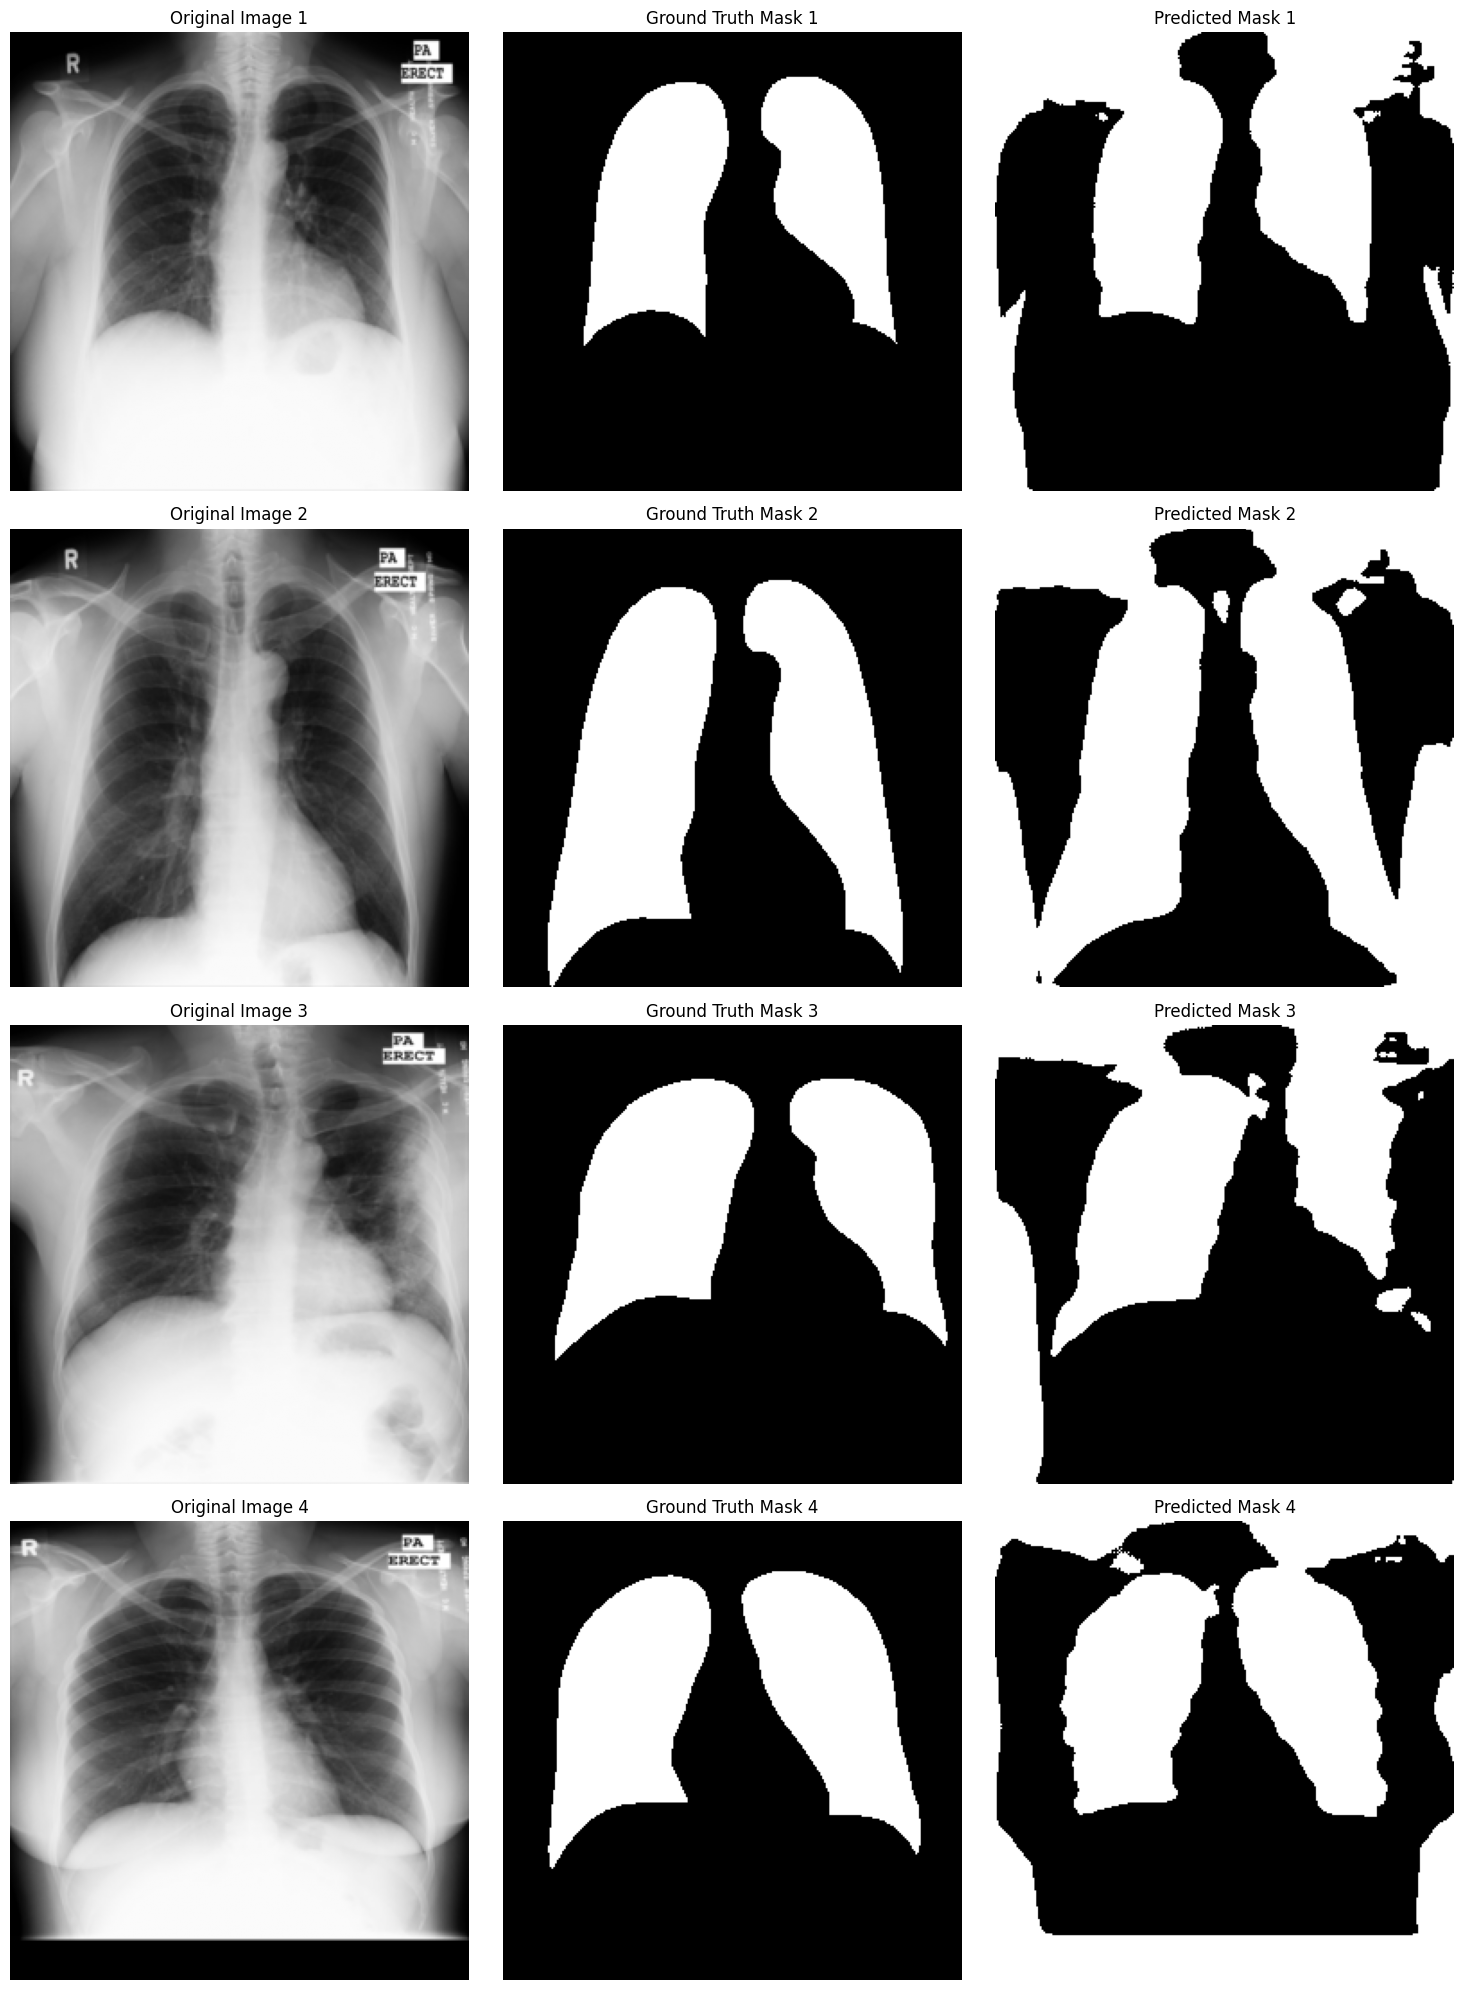

In [9]:
import matplotlib.pyplot as plt

# Get a batch of images and masks from the test loader
dataiter = iter(test_loader)
images, masks = next(dataiter)

# Move images and masks to the device
images = images.to(device)
masks = masks.to(device)

# Get model predictions
model.eval()
with torch.no_grad():
    outputs = model(images)
    predicted_masks = torch.sigmoid(outputs) # Apply sigmoid activation
    predicted_masks = (predicted_masks > 0.5).float() # Threshold to get binary masks

# Visualize a few samples
num_samples_to_show = min(4, images.shape[0]) # Show up to 4 samples

plt.figure(figsize=(15, 5 * num_samples_to_show))
for i in range(num_samples_to_show):
    # Original Image
    plt.subplot(num_samples_to_show, 3, i * 3 + 1)
    plt.imshow(images[i].squeeze().cpu().numpy(), cmap='gray')
    plt.title(f'Original Image {i+1}')
    plt.axis('off')

    # Ground Truth Mask
    plt.subplot(num_samples_to_show, 3, i * 3 + 2)
    plt.imshow(masks[i].squeeze().cpu().numpy(), cmap='gray')
    plt.title(f'Ground Truth Mask {i+1}')
    plt.axis('off')

    # Predicted Mask
    plt.subplot(num_samples_to_show, 3, i * 3 + 3)
    plt.imshow(predicted_masks[i].squeeze().cpu().numpy(), cmap='gray')
    plt.title(f'Predicted Mask {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [10]:
# Save the model's state dictionary
model_save_path = 'unet_lung_segmentation_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to {model_save_path}")

Model weights saved to unet_lung_segmentation_model.pth


In [11]:
# Install Streamlit
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 100.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 119.9 MB/s eta 0:00:00


To run the Streamlit app, execute the following in a new cell:

```bash
!streamlit run app.py & npx localtunnel --port 8501
```

After running, a public URL will be provided by `localtunnel` in the output. Click on that URL to access your Streamlit application.

In [14]:
!pip install pyngrok

In [15]:
from pyngrok import ngrok
ngrok.set_auth_token("3AbwaW53yv021tNxAXrWJumLaDB_7ooi3CHcXxwCCt7XaTCXX")

In [44]:
%%writefile app.py
import streamlit as st
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Model Definition (Must be identical to training) ---
# Re-define all necessary classes (DoubleConv, Down, Up, OutConv, UNet)
# This is crucial for loading the state_dict correctly.

class DoubleConv(nn.Module):
    """ (convolution => [BN] => ReLU) * 2 """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """ Downscaling with maxpool then double conv """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """ Upscaling then double conv """
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()

        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
            self.conv = DoubleConv(in_channels, out_channels)
        else:
            self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
            self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        # input is CHW
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]

        x1 = F.pad(x1, [diffX // 2, diffX - diffX // 2,
                        diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(OutConv, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=False):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        factor = 2 if bilinear else 1
        self.down4 = Down(512, 1024 // factor)
        self.up1 = Up(1024, 512 // factor, bilinear)
        self.up2 = Up(512, 256 // factor, bilinear)
        self.up3 = Up(256, 128 // factor, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits

# --- 2. Load Model ---
@st.cache_resource # Cache the model loading for efficiency
def load_model(model_path='unet_lung_segmentation_model.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = UNet(n_channels=1, n_classes=1) # Initialize with same parameters as training
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    return model, device

model, device = load_model()

# --- 3. Image Transformation ---
image_size = (256, 256) # Must match training input size
transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

# --- 4. Prediction Function ---
def predict_mask(image: Image.Image, model, device, transform):
    # Convert to grayscale if not already, and resize to model input size
    image_gray = image.convert('L')

    input_tensor = transform(image_gray).unsqueeze(0).to(device) # Add batch dimension

    with torch.no_grad():
        output_logits = model(input_tensor)

    # Raw probability map (before thresholding)
    probability_map = torch.sigmoid(output_logits).squeeze().cpu().numpy()

    # Binary predicted mask (after thresholding)
    predicted_mask_binary = (probability_map > 0.5).astype(np.uint8) * 255 # Convert to 0/255 for display

    return Image.fromarray(predicted_mask_binary), Image.fromarray((probability_map * 255).astype(np.uint8))

# --- 5. Streamlit App Interface ---
st.set_page_config(layout="wide", page_title="Lung Segmentation Demo")

st.title("Pulmonary Chest X-Ray Segmentation")
st.write("Upload a chest X-ray image to get a lung segmentation prediction using a trained U-Net model.")
st.write("The model identifies lung regions and generates a corresponding mask.")

# Sidebar for controls
st.sidebar.header("Display Options")
overlay_opacity = st.sidebar.slider("Overlay Opacity", min_value=0.0, max_value=1.0, value=0.5, step=0.05)

uploaded_file = st.file_uploader("Choose an X-ray image (PNG, JPG, JPEG)", type=["png", "jpg", "jpeg"])

if uploaded_file is not None:
    try:
        original_image = Image.open(uploaded_file).convert('RGB') # Convert to RGB for consistent display/overlay
        st.subheader("Uploaded Image")
        st.image(original_image, caption='Original X-ray Image', use_column_width=True)

        with st.spinner('Generating segmentation mask...'):
            predicted_mask_pil_binary, predicted_mask_pil_prob = predict_mask(original_image, model, device, transform)

        st.subheader("Segmentation Results")

        # Create columns for side-by-side display
        col1, col2 = st.columns(2)

        with col1:
            st.image(predicted_mask_pil_binary, caption='Predicted Binary Mask', use_column_width=True)
        with col2:
            # Removed cmap='viridis' as st.image does not support it directly
            st.image(predicted_mask_pil_prob, caption='Predicted Probability Map (Grayscale)', use_column_width=True)

        st.subheader("Overlayed Prediction")
        # Resize the original image to match the mask size for overlay
        # This ensures consistent dimensions for numpy operations
        original_image_resized = original_image.resize(image_size).convert('RGB')
        original_image_resized_np = np.array(original_image_resized)

        # Create a colored mask for overlay (e.g., red)
        mask_colored = np.zeros_like(original_image_resized_np)
        # Use the binary mask for overlay to clearly show the segmented region
        mask_binary_resized_np = np.array(predicted_mask_pil_binary.resize(image_size))

        # Expand norm_mask to 3 channels for broadcasting
        norm_mask_3channel = np.stack([mask_binary_resized_np / 255.0] * 3, axis=-1)

        mask_colored[:, :, 0] = mask_binary_resized_np # Red channel

        # Blend the images
        # Simple alpha blending: (1-alpha)*background + alpha*foreground
        overlayed_image_np = original_image_resized_np * (1 - norm_mask_3channel * overlay_opacity) + mask_colored * (norm_mask_3channel * overlay_opacity)
        overlayed_image_np = np.clip(overlayed_image_np, 0, 255).astype(np.uint8)

        st.image(overlayed_image_np, caption=f'Original Image with Mask Overlay (Opacity: {overlay_opacity*100:.0f}%)', use_column_width=True)

    except Exception as e:
        st.error(f"An error occurred during image processing or prediction: {e}")
        st.warning("Please ensure the uploaded file is a valid image.")
else:
    st.info("Please upload an image to see the segmentation.")

st.markdown("---")
st.info("Note: The U-Net model was trained for a limited number of epochs and serves as a demonstration. Performance can be improved with more extensive training and data augmentation.")

Overwriting app.py


In [45]:
from pyngrok import ngrok

public_url = ngrok.connect(8501)
print(public_url)

NgrokTunnel: "https://foraminate-anders-uncovetous.ngrok-free.dev" -> "http://localhost:8501"


In [ ]:
# Start the Streamlit app in the background
!python -m streamlit run app.py &



2026-07-21 14:28:31.617 Uvicorn server started on :::8502

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8502
  Network URL: http://172.28.0.12:8502
  External URL: http://34.50.178.248:8502

